In [1]:
from pathlib import Path
from typing import Union, Optional
import pandas as pd
import numpy as np
import logging
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)

In [2]:
# Use pathlib for robust path handling
BASE_DIR = Path.cwd().parent 
PROCESSED_DATA_DIR = BASE_DIR / "data_processed"
CONFIG_DIR = BASE_DIR / "config"
BRFSS_ZIP_FILE = PROCESSED_DATA_DIR / "BRFSS_2015_2024.zip"
BRFSS_CLEAN_ZIP_FILE = PROCESSED_DATA_DIR / "BRFSS_2015_2024_cleaned.zip"
RECODE_MAP_FILE = CONFIG_DIR / "recode_mappings.json"

# Ensure directories exist
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
def read_zipped_csv(
    zip_path: Union[str, Path],
    **read_csv_kwargs
) -> pd.DataFrame:
    """
    Read a single-CSV .zip file into a pandas DataFrame.

    Parameters
    ----------
    zip_path : str or Path
        Path to the .zip file (containing exactly one CSV, or a CSV
        with the same name as the zip).
    **read_csv_kwargs :
        Any extra keyword args passed through to pandas.read_csv
        (e.g. sep, dtype, parse_dates).

    Returns
    -------
    pd.DataFrame
    """
    zip_path = Path(zip_path)
    # For a single CSV in the zip, this is enough:
    return pd.read_csv(zip_path, compression="zip", **read_csv_kwargs)

In [4]:
def write_df_to_zipped_csv(
    df: pd.DataFrame,
    zip_path: Union[str, Path],
    csv_name: str | None = None,
    **to_csv_kwargs,
) -> None:
    """
    Write a DataFrame to a CSV stored inside a .zip file.

    Parameters
    ----------
    df : pd.DataFrame
        Data to write.
    zip_path : str or Path
        Path to the .zip file to create, e.g. 'data.zip'.
    csv_name : str, optional
        Name of the CSV file inside the zip, e.g. 'data.csv'.
        If None, uses the zip file stem with '.csv'.
    **to_csv_kwargs :
        Extra keyword args passed to DataFrame.to_csv
        (e.g. index=False, sep=',', encoding='utf-8').
    """
    zip_path = Path(zip_path)
    if csv_name is None:
        csv_name = zip_path.stem + ".csv"

    compression_opts = {
        "method": "zip",
        "archive_name": csv_name,
    }

    df.to_csv(
        zip_path,
        header=True,
        compression=compression_opts,
        **to_csv_kwargs,
    )

In [5]:
# Load the BRFSS data
df = read_zipped_csv(BRFSS_ZIP_FILE)
logging.info(f"Initial data loaded with {df.shape[0]} rows. and columns: {df.shape[1]}")

2026-01-26 23:02:06 - INFO - Initial data loaded with 4410255 rows. and columns: 19


In [6]:
def print_unique_values(data, columnName):
    unique_column_values = data[columnName].unique()
    if pd.api.types.is_numeric_dtype(unique_column_values):
        unique_column_values = np.sort(unique_column_values)
    column_datatype = data[columnName].dtype
    num_unique_column_values = len(unique_column_values)
    print(f'{num_unique_column_values} Unique values in column {columnName} of type {column_datatype}: {unique_column_values}')

# For each column, print unique values
for col in df.columns:
    print_unique_values(df, col)

10 Unique values in column YEAR of type int64: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
7 Unique values in column DIABETES of type float64: [ 1.  2.  3.  4.  7.  9. nan]
14 Unique values in column AGE_CATEGORIES of type float64: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14.]
4 Unique values in column SEX of type float64: [1. 2. 7. 9.]
10 Unique values in column RACE of type float64: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. nan]
7 Unique values in column INCOME of type float64: [ 1.  2.  3.  4.  5.  9. nan]
5 Unique values in column EDUCATION_LEVEL of type float64: [1. 2. 3. 4. 9.]
10 Unique values in column EMPLOYMENT of type float64: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. nan]
8 Unique values in column MARITAL_STATUS of type float64: [ 1.  2.  3.  4.  5.  6.  9. nan]
3 Unique values in column HEALTH_CARE_COVERAGE of type float64: [1. 2. 9.]
5 Unique values in column BMICAT of type float64: [ 1.  2.  3.  4. nan]
3 Unique values in column HEART_ATTACK of type float64: [ 

In [7]:
# For each column, replace 'Not Sure' or 'Refused' codes with NaN

replace_unsure_refused = {
    'HEALTH_STATUS': {9: np.nan},
    'PHYSICAL_HEALTH_STATUS': {9: np.nan},
    'MENTAL_HEALTH_STATUS': {9: np.nan},
    'EXERCISE': {9: np.nan},
    'HEALTH_CARE_COVERAGE': {9: np.nan},
    'SMOKER': {9: np.nan},
    'DRINKER': {7: np.nan, 9: np.nan},
    'SOCIAL_DRINKER': {9: np.nan},
    'HEAVY_ALCOHOL_CONSUMPTION': {9: np.nan},
    #'HEART_ATTACK': {},
    'STROKE': {7: np.nan, 9: np.nan},
    'DIABETES': {7: np.nan, 9: np.nan},
    #'ARTHRITIS': {},
    'MARITAL_STATUS': {9: np.nan},
    'EMPLOYMENT': {9: np.nan},
    'SEX': {7: np.nan, 9: np.nan},
    'AGE_CATEGORIES': {14: np.nan},
    #'BMICAT': {},
    'EDUCATION_LEVEL': {9: np.nan},
    'INCOME': {9: np.nan}
}

df.replace(replace_unsure_refused, inplace=True)

In [8]:
# For each column, print unique values
for col in df.columns:
    print_unique_values(df, col)

10 Unique values in column YEAR of type int64: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
5 Unique values in column DIABETES of type float64: [ 1.  2.  3.  4. nan]
14 Unique values in column AGE_CATEGORIES of type float64: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. nan]
3 Unique values in column SEX of type float64: [ 1.  2. nan]
10 Unique values in column RACE of type float64: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. nan]
6 Unique values in column INCOME of type float64: [ 1.  2.  3.  4.  5. nan]
5 Unique values in column EDUCATION_LEVEL of type float64: [ 1.  2.  3.  4. nan]
9 Unique values in column EMPLOYMENT of type float64: [ 1.  2.  3.  4.  5.  6.  7.  8. nan]
7 Unique values in column MARITAL_STATUS of type float64: [ 1.  2.  3.  4.  5.  6. nan]
3 Unique values in column HEALTH_CARE_COVERAGE of type float64: [ 1.  2. nan]
5 Unique values in column BMICAT of type float64: [ 1.  2.  3.  4. nan]
3 Unique values in column HEART_ATTACK of type float64: [ 1.  2. nan]
3

In [9]:
def recode_column(df, col_name, old_values, new_values):
    if len(old_values) != len(new_values):
        raise ValueError("old_values and new_values must have same length")
    mapping = dict(zip(old_values, new_values))
    df[col_name] = df[col_name].replace(mapping)
    return df

def apply_recode_map(df, map_file=RECODE_MAP_FILE):
    with open(map_file, 'r') as f:
        recode_map = json.load(f)
    
    for col_name, mapping in recode_map.items():
        if mapping.get('multi_step'):
            # Handle grouped (e.g. SMOKER)
            no_codes = mapping['no_codes']
            yes_codes = mapping['yes_codes']
            df.loc[df[col_name].isin(no_codes), col_name] = '0'
            df.loc[df[col_name].isin(yes_codes), col_name] = '1'
        else:
            # Direct 1:1
            old_vals = mapping['old_values']
            new_vals = mapping['new_values']
            df = recode_column(df, col_name, old_vals, new_vals)
    
    # Drop rows with remaining missing values (9, 7, 14, etc.) or set to NaN
    df = df.replace(['9', '7', '14', 'Not sure', 'Refused'], pd.NA)
    
    return df

# Apply to your DataFrame
df = apply_recode_map(df)

In [10]:
# For each column, print unique values
for col in df.columns:
    print_unique_values(df, col)

10 Unique values in column YEAR of type int64: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
5 Unique values in column DIABETES of type float64: [ 1.  2.  3.  4. nan]
14 Unique values in column AGE_CATEGORIES of type float64: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. nan]
3 Unique values in column SEX of type float64: [ 1.  2. nan]
10 Unique values in column RACE of type float64: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. nan]
6 Unique values in column INCOME of type float64: [ 1.  2.  3.  4.  5. nan]
5 Unique values in column EDUCATION_LEVEL of type float64: [ 1.  2.  3.  4. nan]
9 Unique values in column EMPLOYMENT of type float64: [ 1.  2.  3.  4.  5.  6.  7.  8. nan]
7 Unique values in column MARITAL_STATUS of type float64: [ 1.  2.  3.  4.  5.  6. nan]
3 Unique values in column HEALTH_CARE_COVERAGE of type float64: [ 1.  2. nan]
5 Unique values in column BMICAT of type float64: [ 1.  2.  3.  4. nan]
3 Unique values in column HEART_ATTACK of type float64: [ 1.  2. nan]
3

In [11]:
# Drop duplicate rows
logging.info("Dropping duplicate rows from the dataset.")
initial_row_count = df.shape[0]
df.drop_duplicates(inplace=True)
logging.info(f"Data after dropping duplicates has {df.shape[0]} rows (dropped {initial_row_count - df.shape[0]} duplicates).")

2026-01-26 23:02:14 - INFO - Dropping duplicate rows from the dataset.
2026-01-26 23:02:16 - INFO - Data after dropping duplicates has 3147163 rows (dropped 1263092 duplicates).


In [12]:
# Cleanse and process the data as needed
logging.info("Dropping rows with missing data.")
initial_row_count = df.shape[0]
df.dropna(inplace=True)
logging.info(f"Data after dropping missing rows has {df.shape[0]} rows (dropped {initial_row_count - df.shape[0]} missing data rows).")

2026-01-26 23:02:16 - INFO - Dropping rows with missing data.
2026-01-26 23:02:16 - INFO - Data after dropping missing rows has 1307280 rows (dropped 1839883 missing data rows).


In [13]:
# For each column, print unique values
for col in df.columns:
    print_unique_values(df, col)

10 Unique values in column YEAR of type int64: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
4 Unique values in column DIABETES of type float64: [1. 2. 3. 4.]
9 Unique values in column AGE_CATEGORIES of type float64: [1. 2. 3. 4. 5. 6. 7. 8. 9.]
2 Unique values in column SEX of type float64: [1. 2.]
9 Unique values in column RACE of type float64: [1. 2. 3. 4. 5. 6. 7. 8. 9.]
5 Unique values in column INCOME of type float64: [1. 2. 3. 4. 5.]
4 Unique values in column EDUCATION_LEVEL of type float64: [1. 2. 3. 4.]
8 Unique values in column EMPLOYMENT of type float64: [1. 2. 3. 4. 5. 6. 7. 8.]
6 Unique values in column MARITAL_STATUS of type float64: [1. 2. 3. 4. 5. 6.]
2 Unique values in column HEALTH_CARE_COVERAGE of type float64: [1. 2.]
4 Unique values in column BMICAT of type float64: [1. 2. 3. 4.]
2 Unique values in column HEART_ATTACK of type float64: [1. 2.]
2 Unique values in column STROKE of type float64: [1. 2.]
3 Unique values in column EXERCISE of type float64: [1. 2. 7

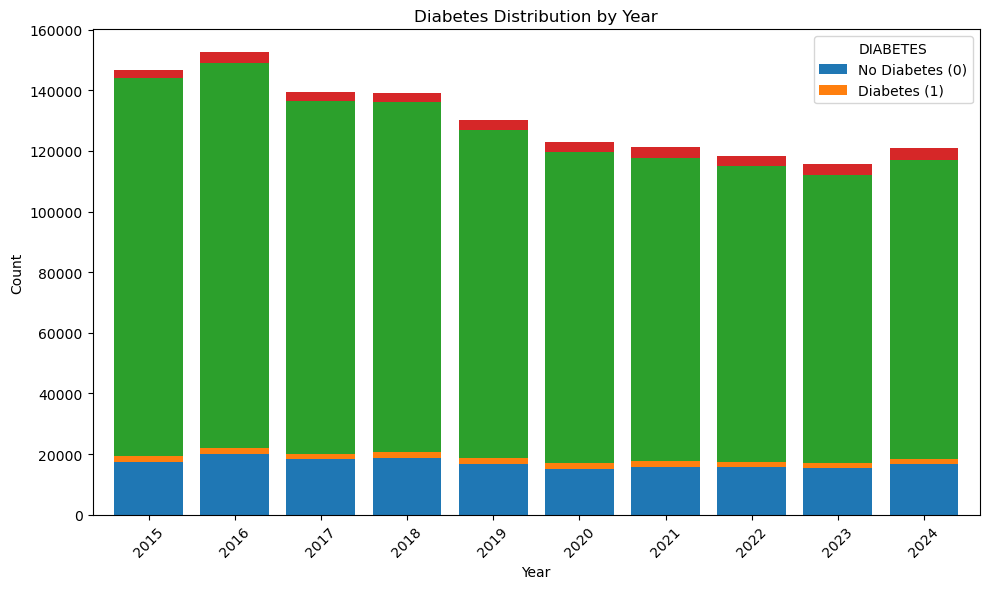

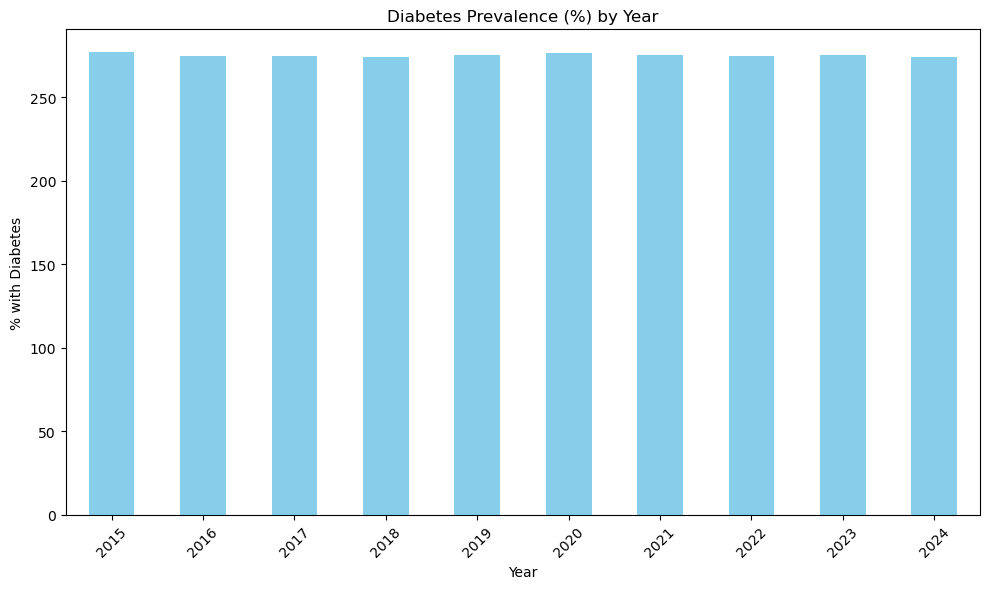

In [14]:
# Assuming df is your recoded DataFrame with 'DIABETES' (0=No, 1=Yes) and 'YEAR' columns
# If YEAR column name differs (e.g. 'year', 'survey_year'), adjust accordingly

# Group by year and diabetes status, count occurrences
diabetes_by_year = df.groupby(['YEAR', 'DIABETES']).size().unstack(fill_value=0)

# Plot stacked bar chart (total N per year, proportion diabetes)
fig, ax = plt.subplots(figsize=(10, 6))
diabetes_by_year.plot(kind='bar', stacked=True, ax=ax, width=0.8)

ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.set_title('Diabetes Distribution by Year')
ax.legend(['No Diabetes (0)', 'Diabetes (1)'], title='DIABETES')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Alternative: proportion of diabetes per year
diabetes_pct = df.groupby('YEAR')['DIABETES'].mean() * 100
diabetes_pct.plot(kind='bar', color='skyblue', figsize=(10, 6))
plt.title('Diabetes Prevalence (%) by Year')
plt.ylabel('% with Diabetes')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


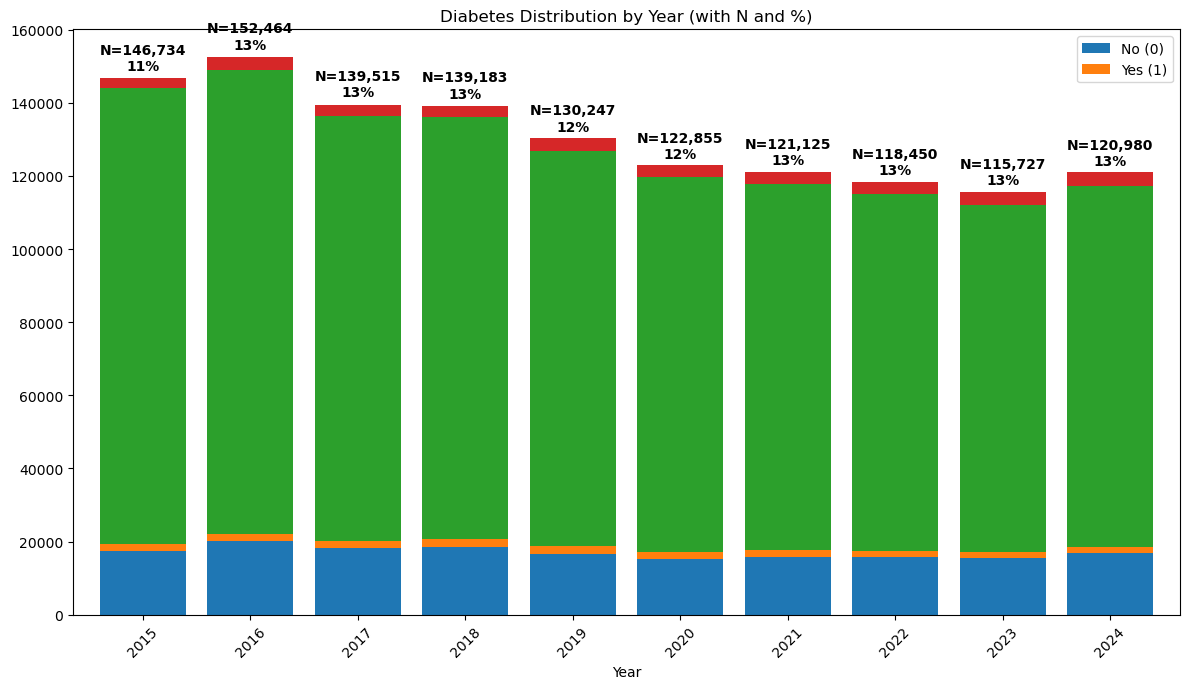

In [15]:
diabetes_by_year = df.groupby(['YEAR', 'DIABETES']).size().unstack(fill_value=0)
totals = diabetes_by_year.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 7))
bars = diabetes_by_year.plot(kind='bar', stacked=True, ax=ax, width=0.8)

# Add total N and % labels on top of each bar
for i, (year, total) in enumerate(totals.items()):
    diabetes_n = diabetes_by_year.loc[year, 1] if 1 in diabetes_by_year.columns else 0
    pct = (diabetes_n / total * 100).round(1)
    ax.text(i, total + total*0.01, f'N={total:,}\n{int(pct)}%', 
            ha='center', va='bottom', fontweight='bold')

ax.set_title('Diabetes Distribution by Year (with N and %)')
ax.legend(['No (0)', 'Yes (1)'])
ax.set_xlabel('Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
logging.info("Data information:\n")
df.info()

2026-01-26 23:02:18 - INFO - Data information:



<class 'pandas.core.frame.DataFrame'>
Index: 1307280 entries, 0 to 4410254
Data columns (total 19 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   YEAR                       1307280 non-null  int64  
 1   DIABETES                   1307280 non-null  float64
 2   AGE_CATEGORIES             1307280 non-null  float64
 3   SEX                        1307280 non-null  float64
 4   RACE                       1307280 non-null  float64
 5   INCOME                     1307280 non-null  float64
 6   EDUCATION_LEVEL            1307280 non-null  float64
 7   EMPLOYMENT                 1307280 non-null  float64
 8   MARITAL_STATUS             1307280 non-null  float64
 9   HEALTH_CARE_COVERAGE       1307280 non-null  float64
 10  BMICAT                     1307280 non-null  float64
 11  HEART_ATTACK               1307280 non-null  float64
 12  STROKE                     1307280 non-null  float64
 13  EXERCISE         

In [17]:
logging.info("Data description:\n")
df.describe()

2026-01-26 23:02:18 - INFO - Data description:



,YEAR,DIABETES,AGE_CATEGORIES,SEX,RACE,INCOME,EDUCATION_LEVEL,EMPLOYMENT,MARITAL_STATUS,HEALTH_CARE_COVERAGE,BMICAT,HEART_ATTACK,STROKE,EXERCISE,SMOKER,HEAVY_ALCOHOL_CONSUMPTION,HEALTH_STATUS,POOR_PHYSICAL_HEALTH_DAYS,POOR_MENTAL_HEALTH_DAYS
count,1.307280e+06,1.307280e+06,1.307280e+06,1.307280e+06,1.307280e+06,1.307280e+06,1.307280e+06,1.307280e+06,1.307280e+06,1.307280e+06,1.307280e+06,1.307280e+06,1.307280e+06,1.307280e+06,1.307280e+06,1.307280e+06,1.307280e+06,1.307280e+06,1.307280e+06
mean,2.019249e+03,2.750926e+00,5.653568e+00,1.530410e+00,2.659565e+00,3.610136e+00,2.843788e+00,2.967016e+00,2.735957e+00,1.134752e+00,3.076163e+00,1.933134e+00,1.963913e+00,1.295768e+00,3.116383e+00,1.094232e+00,1.231120e+00,7.411845e+00,7.479755e+00
std,2.885632e+00,7.061124e-01,2.607741e+00,4.990746e-01,2.704072e+00,1.459131e+00,9.531950e-01,2.615721e+00,1.865472e+00,3.414589e-01,8.544836e-01,2.497891e-01,1.865071e-01,4.902298e-01,1.111443e+00,2.921507e-01,4.215489e-01,2.063528e+01,2.061509e+01
min,2.015000e+03,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,2.017000e+03,3.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,1.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
50%,2.019000e+03,3.000000e+00,6.000000e+00,2.000000e+00,1.000000e+00,4.000000e+00,3.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00,3.000000e+00,2.000000e+00,2.000000e+00,1.000000e+00,4.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00
75%,2.022000e+03,3.000000e+00,8.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00,4.000000e+00,5.000000e+00,5.000000e+00,1.000000e+00,4.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,4.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,3.000000e+00
max,2.024000e+03,4.000000e+00,9.000000e+00,2.000000e+00,9.000000e+00,5.000000e+00,4.000000e+00,8.000000e+00,6.000000e+00,2.000000e+00,4.000000e+00,2.000000e+00,2.000000e+00,7.000000e+00,4.000000e+00,2.000000e+00,2.000000e+00,9.900000e+01,9.900000e+01


In [18]:
logging.info("First few rows of the dataset:")
df.head()

2026-01-26 23:02:19 - INFO - First few rows of the dataset:


,YEAR,DIABETES,AGE_CATEGORIES,SEX,RACE,INCOME,EDUCATION_LEVEL,EMPLOYMENT,MARITAL_STATUS,HEALTH_CARE_COVERAGE,BMICAT,HEART_ATTACK,STROKE,EXERCISE,SMOKER,HEAVY_ALCOHOL_CONSUMPTION,HEALTH_STATUS,POOR_PHYSICAL_HEALTH_DAYS,POOR_MENTAL_HEALTH_DAYS
0,2015,3.0,9.0,2.0,1.0,2.0,2.0,8.0,1.0,1.0,4.0,2.0,2.0,2.0,3.0,1.0,2.0,15.0,18.0
1,2015,3.0,7.0,2.0,1.0,1.0,4.0,3.0,2.0,2.0,3.0,2.0,2.0,1.0,1.0,1.0,1.0,88.0,88.0
3,2015,3.0,9.0,2.0,1.0,5.0,2.0,8.0,1.0,1.0,3.0,2.0,2.0,2.0,4.0,1.0,2.0,30.0,30.0
10,2015,3.0,9.0,2.0,1.0,5.0,4.0,7.0,1.0,1.0,4.0,2.0,2.0,2.0,3.0,1.0,1.0,14.0,88.0
16,2015,1.0,9.0,2.0,1.0,1.0,3.0,8.0,6.0,1.0,4.0,1.0,2.0,2.0,1.0,1.0,2.0,30.0,30.0


In [19]:
logging.info(f"The BRFSS 2015-2024 dataset has been successfully prepared and is ready for analysis and had {df.shape[0]} rows and {df.shape[1]} columns.")

2026-01-26 23:02:19 - INFO - The BRFSS 2015-2024 dataset has been successfully prepared and is ready for analysis and had 1307280 rows and 19 columns.


In [20]:
logging.info("Write the cleaned dataset to csv")
write_df_to_zipped_csv(df, BRFSS_CLEAN_ZIP_FILE, index=False)

2026-01-26 23:02:19 - INFO - Write the cleaned dataset to csv
